# Mapping and GeoPandas

By: Dr. Eric Godat

So far, we have explored data using tables, filtering, sorting, summary
statistics, and plots.

But many datasets also have a geographic component. Maps can reveal
patterns that are difficult to see in a table or a scatterplot.

In this notebook, we will use **GeoPandas** to:

- load geographic data
- inspect geometry columns
- calculate areas, centroids, and distances
- create buffers
- test spatial relationships
- merge geographic data with ACS data
- map missing data
- create choropleth maps

The goal is not to become a GIS expert today. The goal is to understand
that **location is data**.

# Setup

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

# 1. Reading Geographic Data

GeoPandas works a lot like pandas, but it adds special support for
geographic shapes.

Those shapes are stored in a special column called `geometry`.

Today we will use a GeoJSON file containing Texas county boundaries.

In [2]:
import shapely
import numpy as np
import fiona
counties = gpd.read_file("data/tx_counties.geojson", engine="fiona")

In [3]:
pip install --upgrade geopandas shapely

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install --upgrade geopandas fiona

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


If you get a If you receive a geometry-related error, update geopandas/shapely using the code below and restart the kernel.
```
pip install --upgrade geopandas shapely
```

This will upgrade the version of these packages in our environment to a newer version and resolve our error.

In [5]:
counties.head()

,STATE,COUNTY,FIPS,STATE_FIPS,SQUARE_MIL,geometry
0,TX,Sherman County,48421,48,923.287,"POLYGON ((-101.62346 36.06313, -101.62346 36.0..."
1,TX,Hansford County,48195,48,920.256,"POLYGON ((-101.08571 36.05757, -101.08573 36.0..."
2,TX,Dallam County,48111,48,1505.146,"POLYGON ((-103.04191 36.50043, -103.00242 36.5..."
3,TX,Ochiltree County,48357,48,917.959,"POLYGON ((-100.54614 36.49934, -100.54611 36.4..."
4,TX,Lipscomb County,48295,48,932.089,"POLYGON ((-100.00039 36.06712, -100.00039 36.0..."


The full dataset may contain more columns than we need. Let’s look at
just the most useful ones.

In [6]:
counties[["COUNTY", "FIPS", "SQUARE_MIL", "geometry"]].head()

,COUNTY,FIPS,SQUARE_MIL,geometry
0,Sherman County,48421,923.287,"POLYGON ((-101.62346 36.06313, -101.62346 36.0..."
1,Hansford County,48195,920.256,"POLYGON ((-101.08571 36.05757, -101.08573 36.0..."
2,Dallam County,48111,1505.146,"POLYGON ((-103.04191 36.50043, -103.00242 36.5..."
3,Ochiltree County,48357,917.959,"POLYGON ((-100.54614 36.49934, -100.54611 36.4..."
4,Lipscomb County,48295,932.089,"POLYGON ((-100.00039 36.06712, -100.00039 36.0..."


Each row is one county.

The `geometry` column contains the county shape.

# 2. Our First Map

GeoPandas can draw the shapes in the geometry column directly.

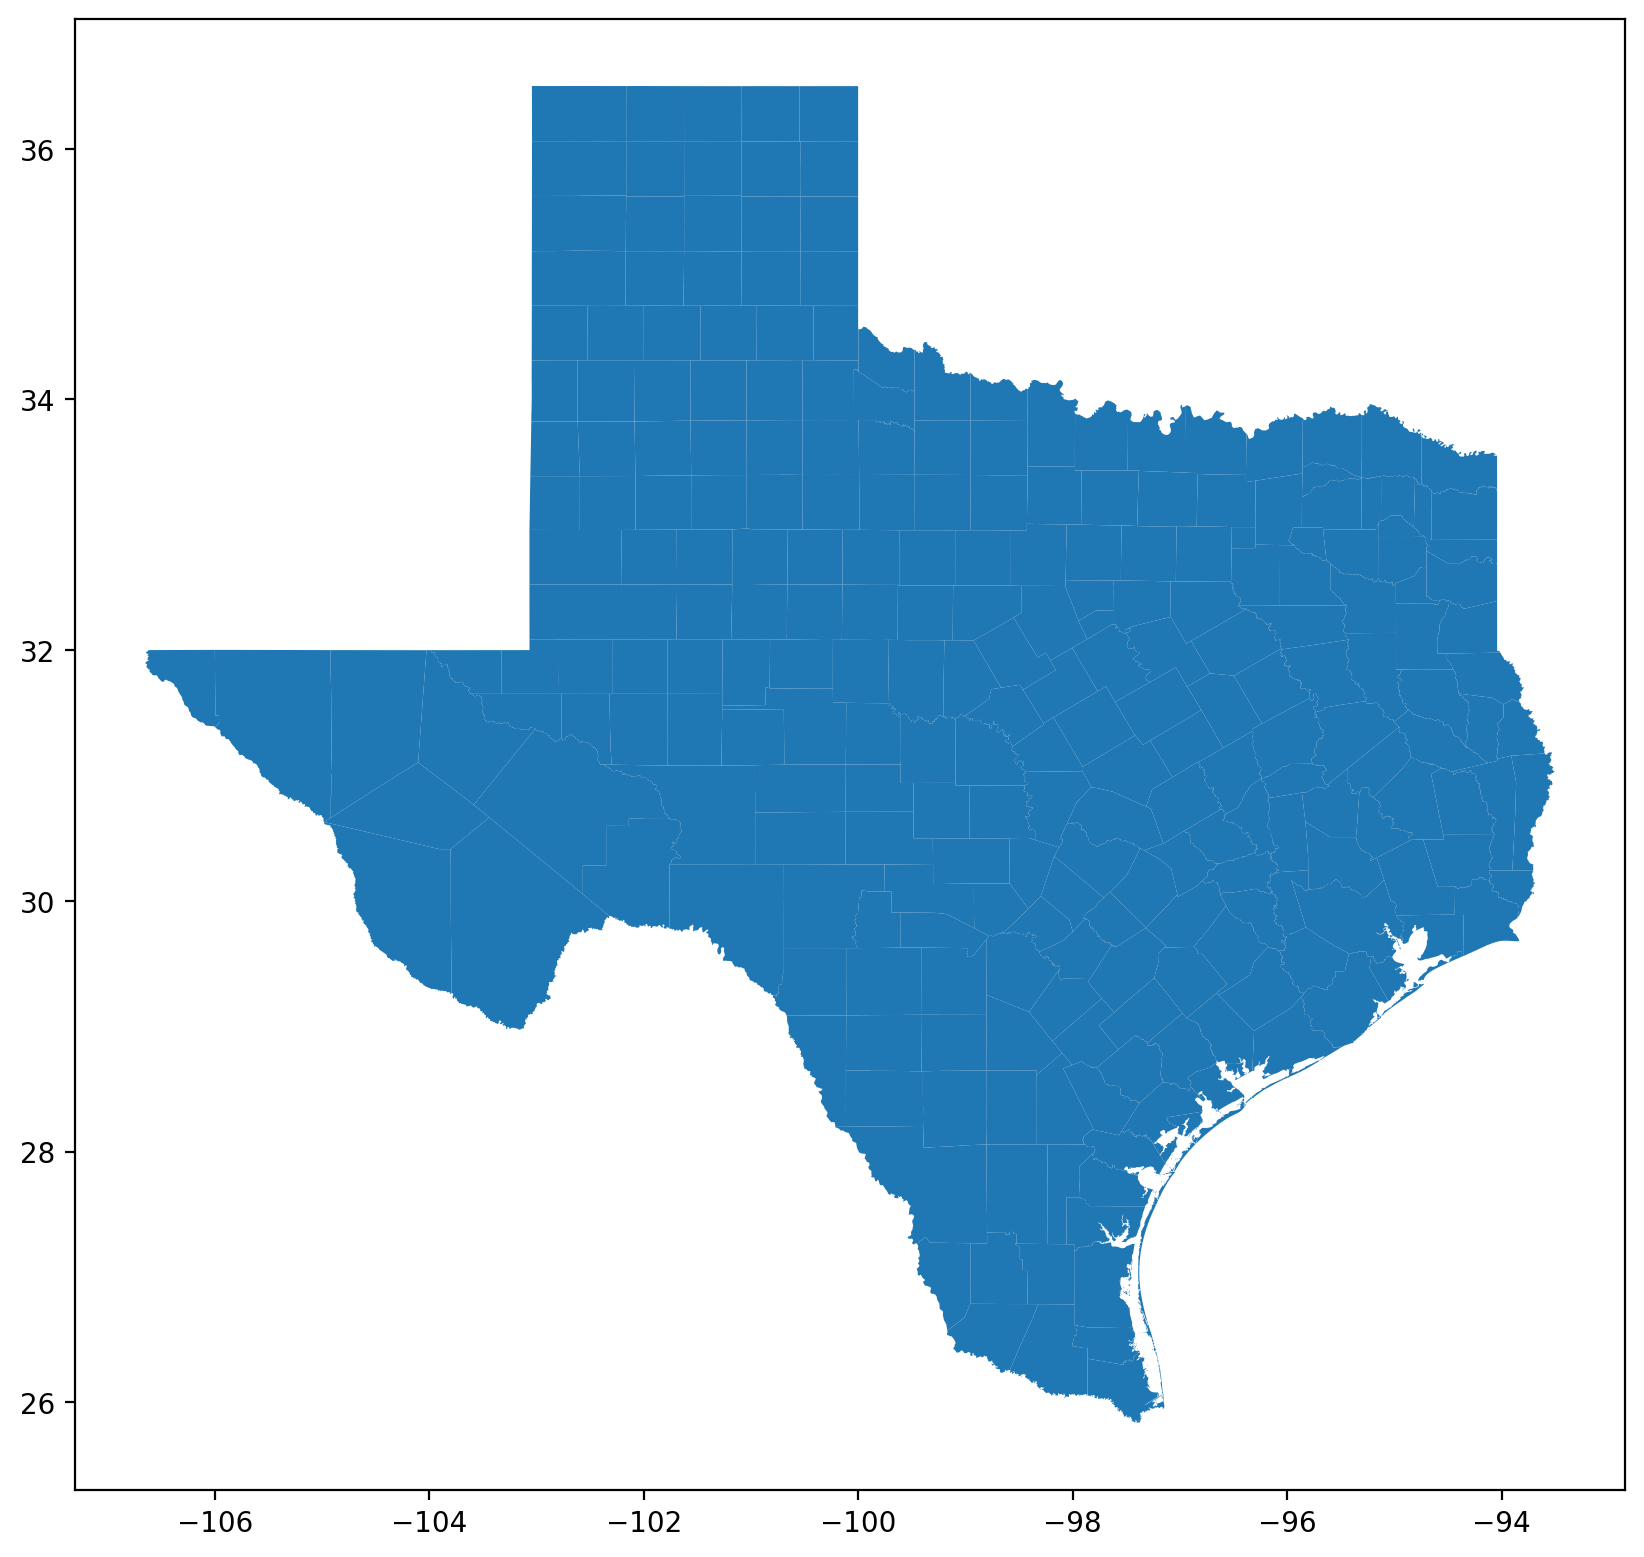

In [7]:
counties.plot(figsize=(10, 10));

That single line made a map.

This is the basic idea of GeoPandas:

> pandas dataframe + geometry column = mappable data

# 3. Geometry as Data

The geometry column is not just for drawing maps. We can calculate
things from it.

For example, we can calculate:

- area
- boundaries
- centroids
- distances
- buffers
- intersections

## Area

The dataset already includes a `SQUARE_MIL` column, but GeoPandas can
also calculate area from the geometry.

In [8]:
counties["geometry_area"] = counties.area

/tmp/ipykernel_1853748/2127068569.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  counties["geometry_area"] = counties.area


In [9]:
counties[["COUNTY", "SQUARE_MIL", "geometry_area"]].head()

,COUNTY,SQUARE_MIL,geometry_area
0,Sherman County,923.287,0.239853
1,Hansford County,920.256,0.239065
2,Dallam County,1505.146,0.390991
3,Ochiltree County,917.959,0.238461
4,Lipscomb County,932.089,0.242137


Map projections affect area calculations, so `geometry_area` is not
always in units that are easy to interpret.

If we need to calculate area, we first project the data into a coordinate system designed for Texas: EPSG:3083.

In [10]:
counties_projected = counties.to_crs("EPSG:3083")

In [11]:
counties_projected["area_sq_miles"] = (
    counties_projected.geometry.area / 2589988.11 #1 square mile = 2,589,988.11 square meters
)

In [12]:
counties_projected[["COUNTY", "SQUARE_MIL","area_sq_miles"]].sort_values(
    by="SQUARE_MIL",
    ascending=False
).head()

,COUNTY,SQUARE_MIL,area_sq_miles
181,Brewster County,6192.396,6192.420404
157,Pecos County,4764.812,4764.831613
130,Hudspeth County,4571.312,4571.265040
183,Presidio County,3855.419,3855.434572
129,Culberson County,3815.937,3815.921743


For today, we will use the provided `SQUARE_MIL` column when
we want county area in square miles.

In [13]:
counties.sort_values(by="SQUARE_MIL", ascending=False)[["COUNTY", "SQUARE_MIL"]].head(10)

,COUNTY,SQUARE_MIL
181,Brewster County,6192.396
157,Pecos County,4764.812
130,Hudspeth County,4571.312
183,Presidio County,3855.419
129,Culberson County,3815.937
240,Webb County,3375.196
194,Val Verde County,3232.616
168,Crockett County,2807.477
133,Reeves County,2641.998
182,Terrell County,2357.714


## Discussion

Which counties are physically largest?

Are those also the most populated counties?

# 4. Boundaries and Centroids

GeoPandas can extract the boundary of each polygon.

In [14]:
counties_projected["boundary"] = counties_projected.boundary

It can also calculate the centroid, or geometric center, of each county.

In [15]:
counties_projected["centroid"] = counties_projected.centroid
# the centroid is if you fold a polygon in half, then in half again
# imagine the centroid of Hawaii... that would be weird & in the middle of the ocean
# the centroid mathematically is the average x and the average y

In [16]:
counties_projected[["COUNTY", "boundary", "centroid"]].head()

,COUNTY,boundary,centroid
0,Sherman County,"LINESTRING (1353531.629 7994292.661, 1353519.2...",POINT (1329582.313 8018434.336)
1,Hansford County,"LINESTRING (1402039.571 7993081.861, 1402035.3...",POINT (1378081.91 8017688.094)
2,Dallam County,"LINESTRING (1226914.448 8045408.138, 1230458.6...",POINT (1265802.834 8019763.966)
3,Ochiltree County,"LINESTRING (1450964.456 8041654.74, 1450961.25...",POINT (1426587.75 8017316.512)
4,Lipscomb County,"LINESTRING (1499964.75 7993659.538, 1499964.76...",POINT (1475416.475 8016999.439)


Let’s plot county boundaries and county centroids together.

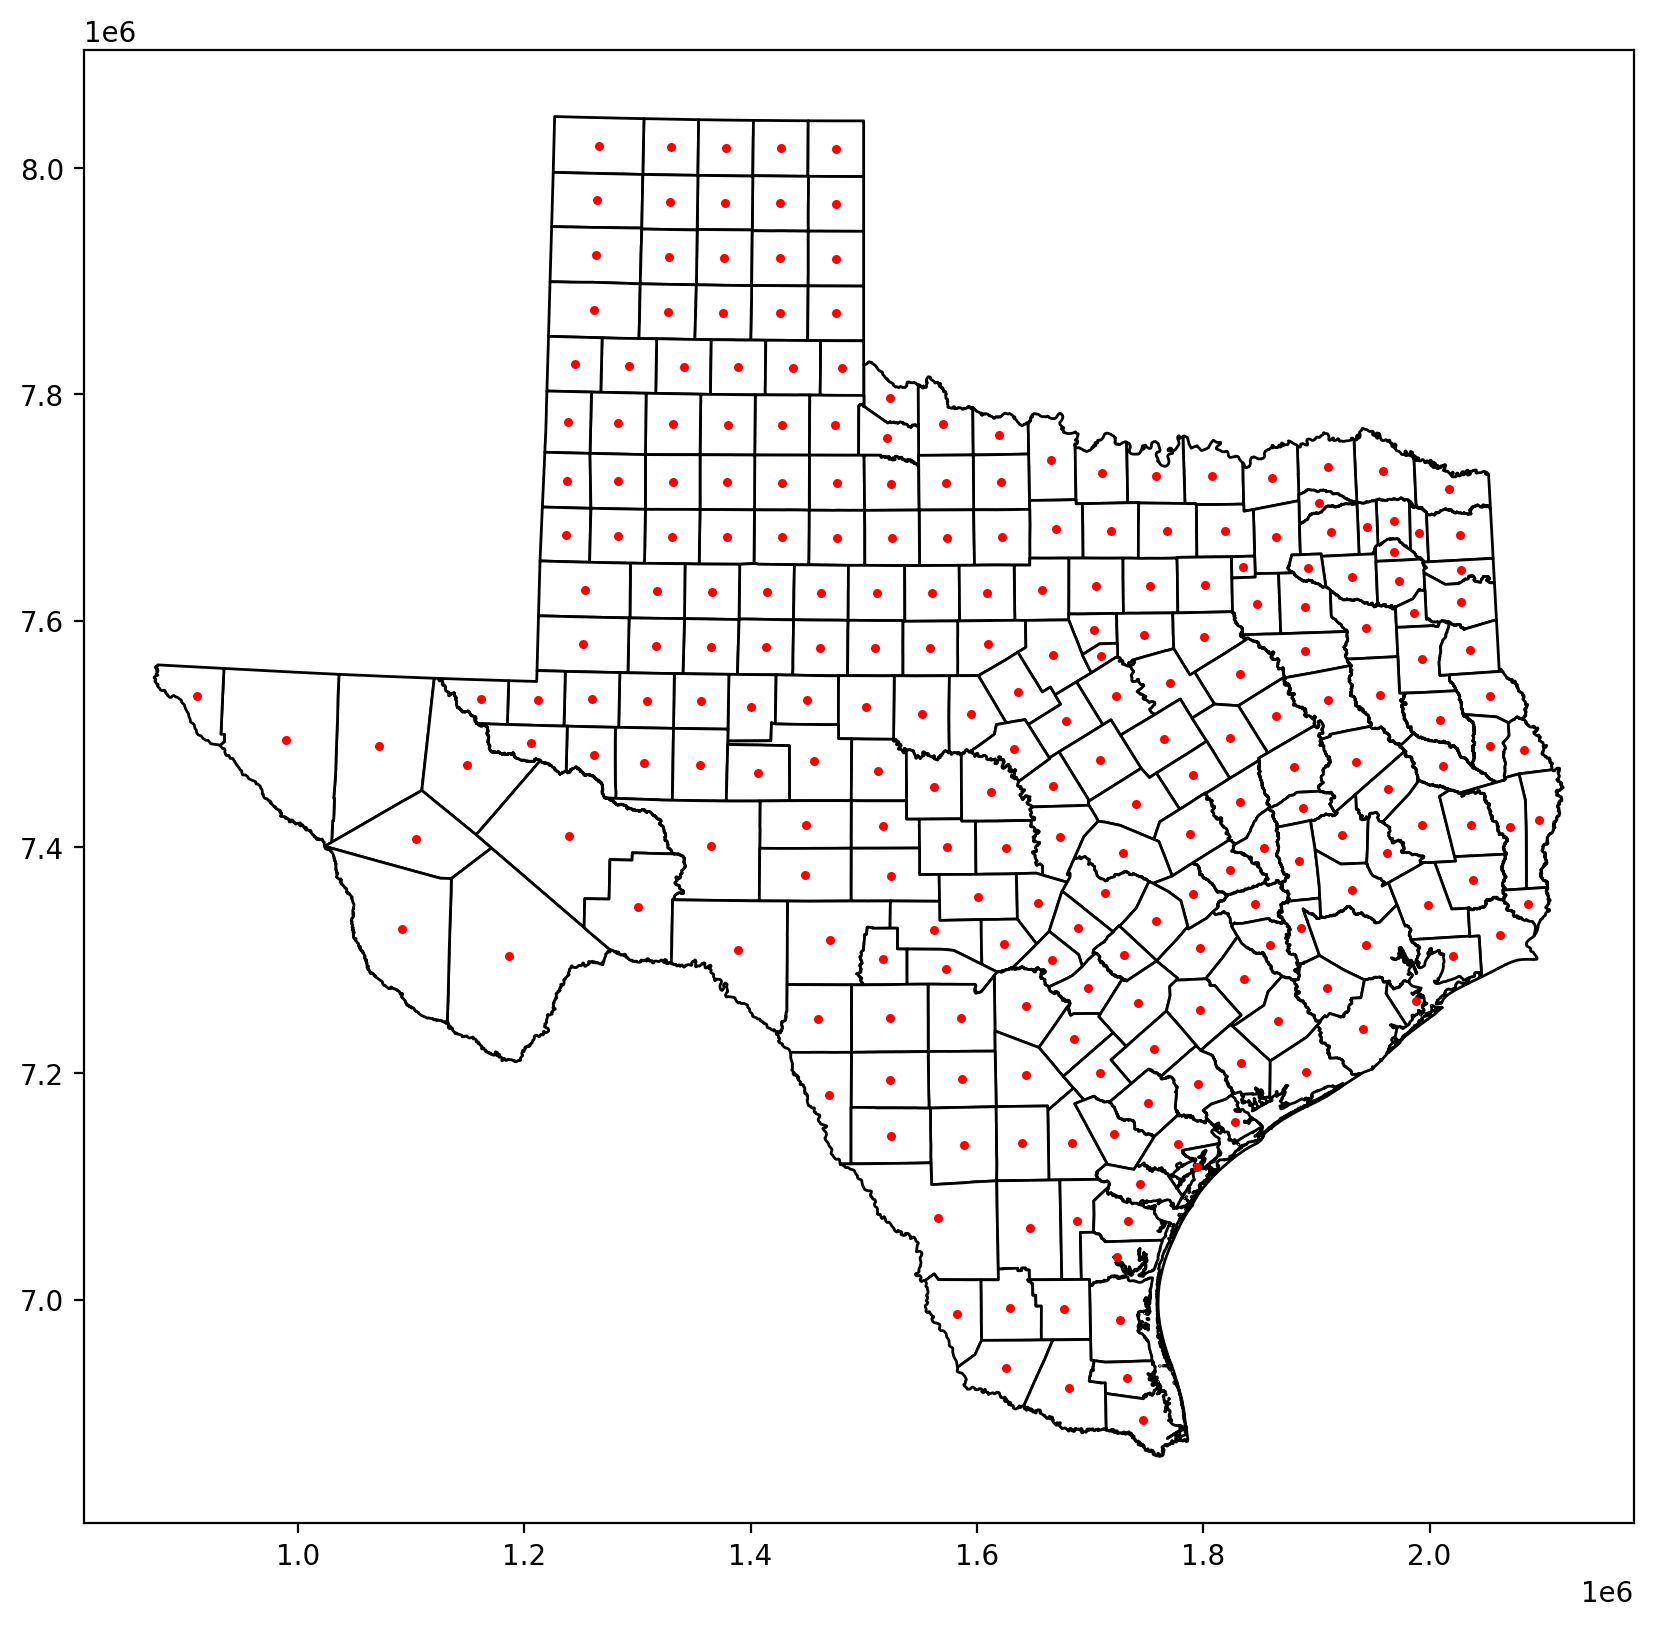

In [18]:
ax = counties_projected.plot(color="white", edgecolor="black", figsize=(10, 10))
counties_projected.set_geometry("centroid").plot(ax=ax, color="red", markersize=5);
# we are actually layering maps
# our projection is white, our edge colors are black, then we took a second graph and stacked a collection of different axes

## Discussion

Is the geographic center of a county always where people live?

Why might centroids be useful anyway?

# 5. Distance

We can measure distance between geometries.

Let’s pick Dallas County and calculate the distance from every county
centroid to the Dallas County centroid.

In [22]:
dallas_centroid = counties_projected.loc[counties_projected["COUNTY"] == "Dallas County", "centroid"].iloc[0]
# fancy traditional slicing... pulls Dallas centroid, finds the distances to it from each other centroid
# loc allows you to select
# iloc is select off of index

In [23]:
counties_projected["distance_to_dallas"] = counties_projected["centroid"].distance(dallas_centroid)

In [24]:
counties_projected.sort_values(by="distance_to_dallas")[["COUNTY", "distance_to_dallas"]].head(10)

,COUNTY,distance_to_dallas
78,Dallas County,0.000000
79,Rockwall County,37535.965373
98,Ellis County,46485.085166
77,Tarrant County,48075.028238
91,Kaufman County,49487.904638
58,Collin County,50580.720204
56,Denton County,58013.376444
97,Johnson County,69974.677295
57,Hunt County,75820.269961
111,Navarro County,84937.147348


The distance values depend on the coordinate system of the file, so we
will treat them as useful for comparison rather than as precise miles.

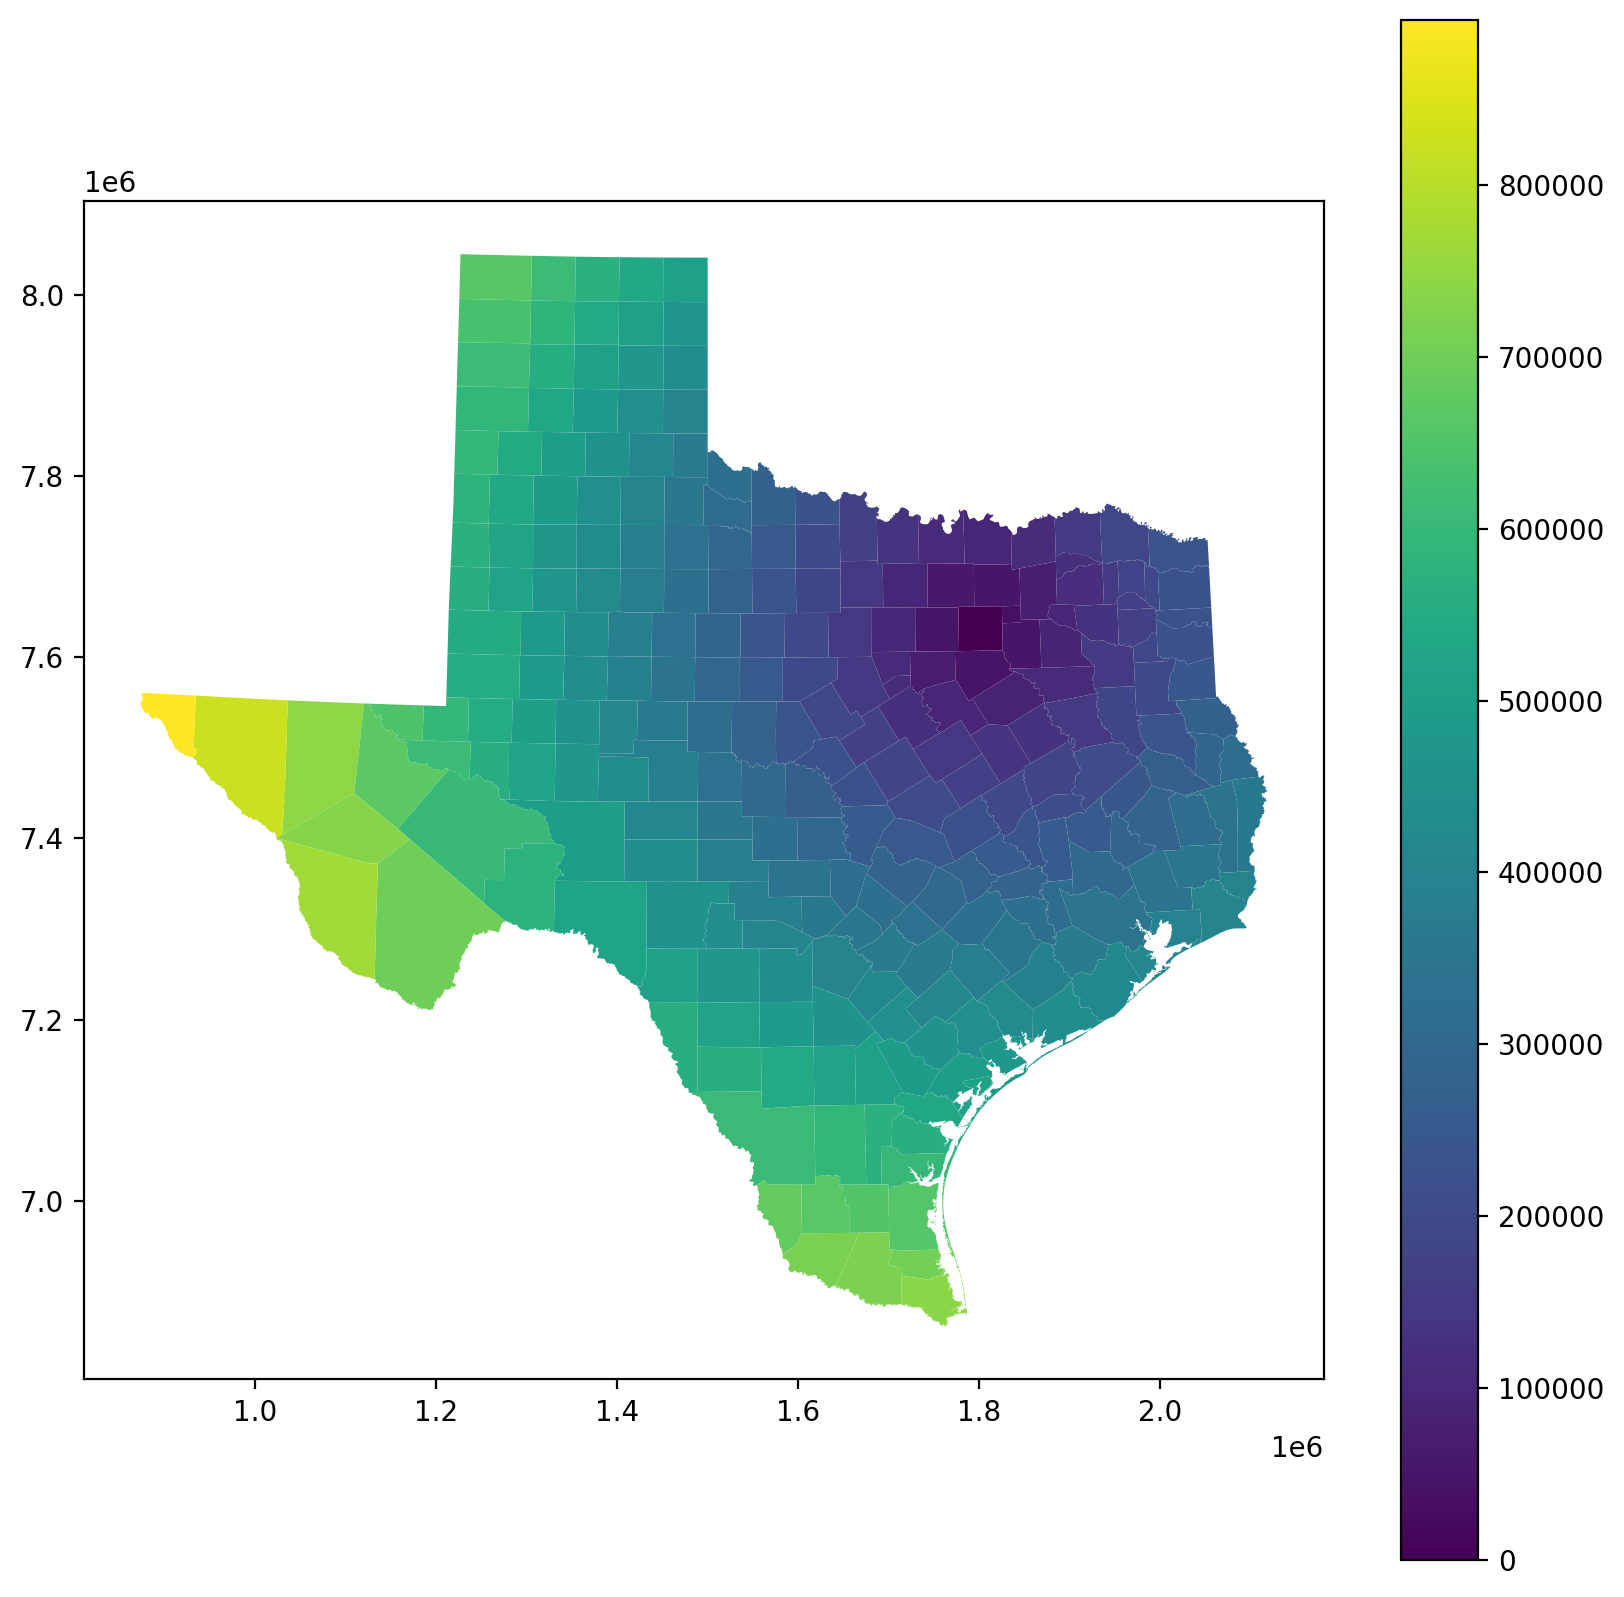

In [25]:
counties_projected.plot(column="distance_to_dallas", legend=True, figsize=(10, 10));

## Discussion

What pattern do you expect to see before running the map?

Does the map match your intuition?

# 6. Buffers

A buffer creates an area around a geometry.

You can think of this as asking:

> What is within some distance of this place?


In [33]:
dallas_geometry = counties_projected.loc[counties_projected["COUNTY"] == "Dallas County", "geometry"].iloc[0]
# wanna know walking distance from your favorite coffee shop?
# a buffer says 'give me a shape around a specified object'
# you could collect all the coffee shops within a 100 meter radius of your current location

In [34]:
dallas_buffer = dallas_geometry.buffer(100000) # EPSG:3083 uses meters, so 100 km = 100,000 meters

In [35]:
# dallas_buffer = dallas_geometry.buffer(10000) # EPSG:3083 uses meters, so 100 km = 100,000 meters

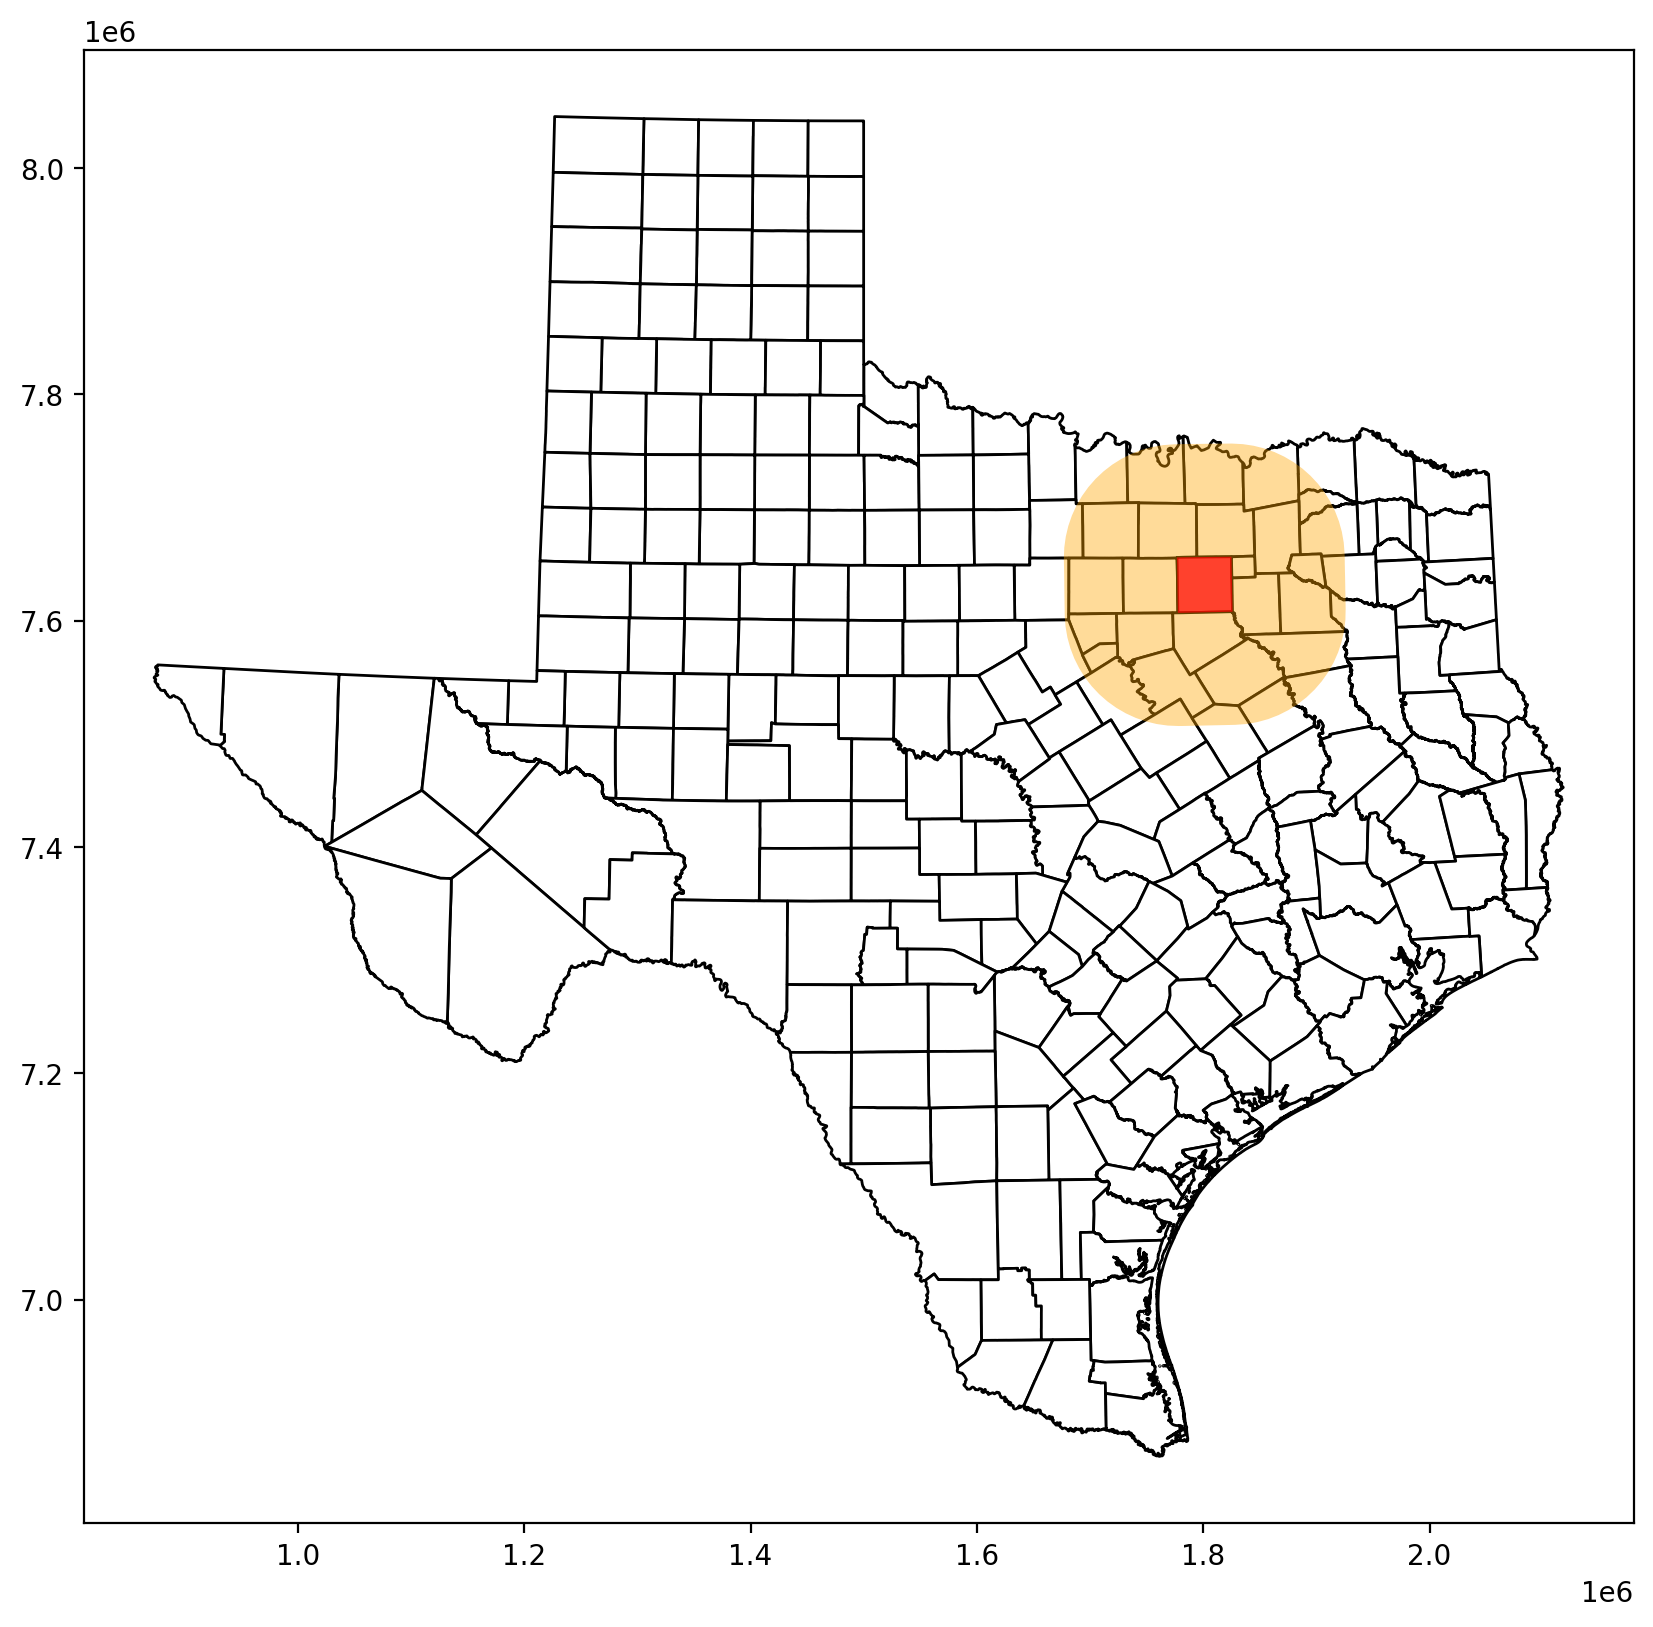

In [36]:
ax = counties_projected.plot(color="white", edgecolor="black", figsize=(10, 10))
gpd.GeoSeries([dallas_buffer], crs=counties_projected.crs).plot(ax=ax, color="orange", alpha=0.4)
gpd.GeoSeries([dallas_geometry], crs=counties_projected.crs).plot(ax=ax, color="red", alpha=0.7);

## Discussion

What might a buffer represent in a real project?

Examples:

- distance from a school
- distance from a grocery store
- distance from a transit stop
- distance from a shelter
- distance from a park

# 7. Spatial Relationships

Spatial data lets us ask questions that ordinary tables cannot answer
directly.

For example:

> Which counties touch Dallas County?

In [40]:
counties_projected["touches_dallas"] = counties_projected.touches(dallas_geometry)

In [41]:
counties_projected[counties_projected["touches_dallas"]][["COUNTY", "touches_dallas"]]

,COUNTY,touches_dallas
56,Denton County,True
58,Collin County,True
77,Tarrant County,True
79,Rockwall County,True
91,Kaufman County,True
98,Ellis County,True


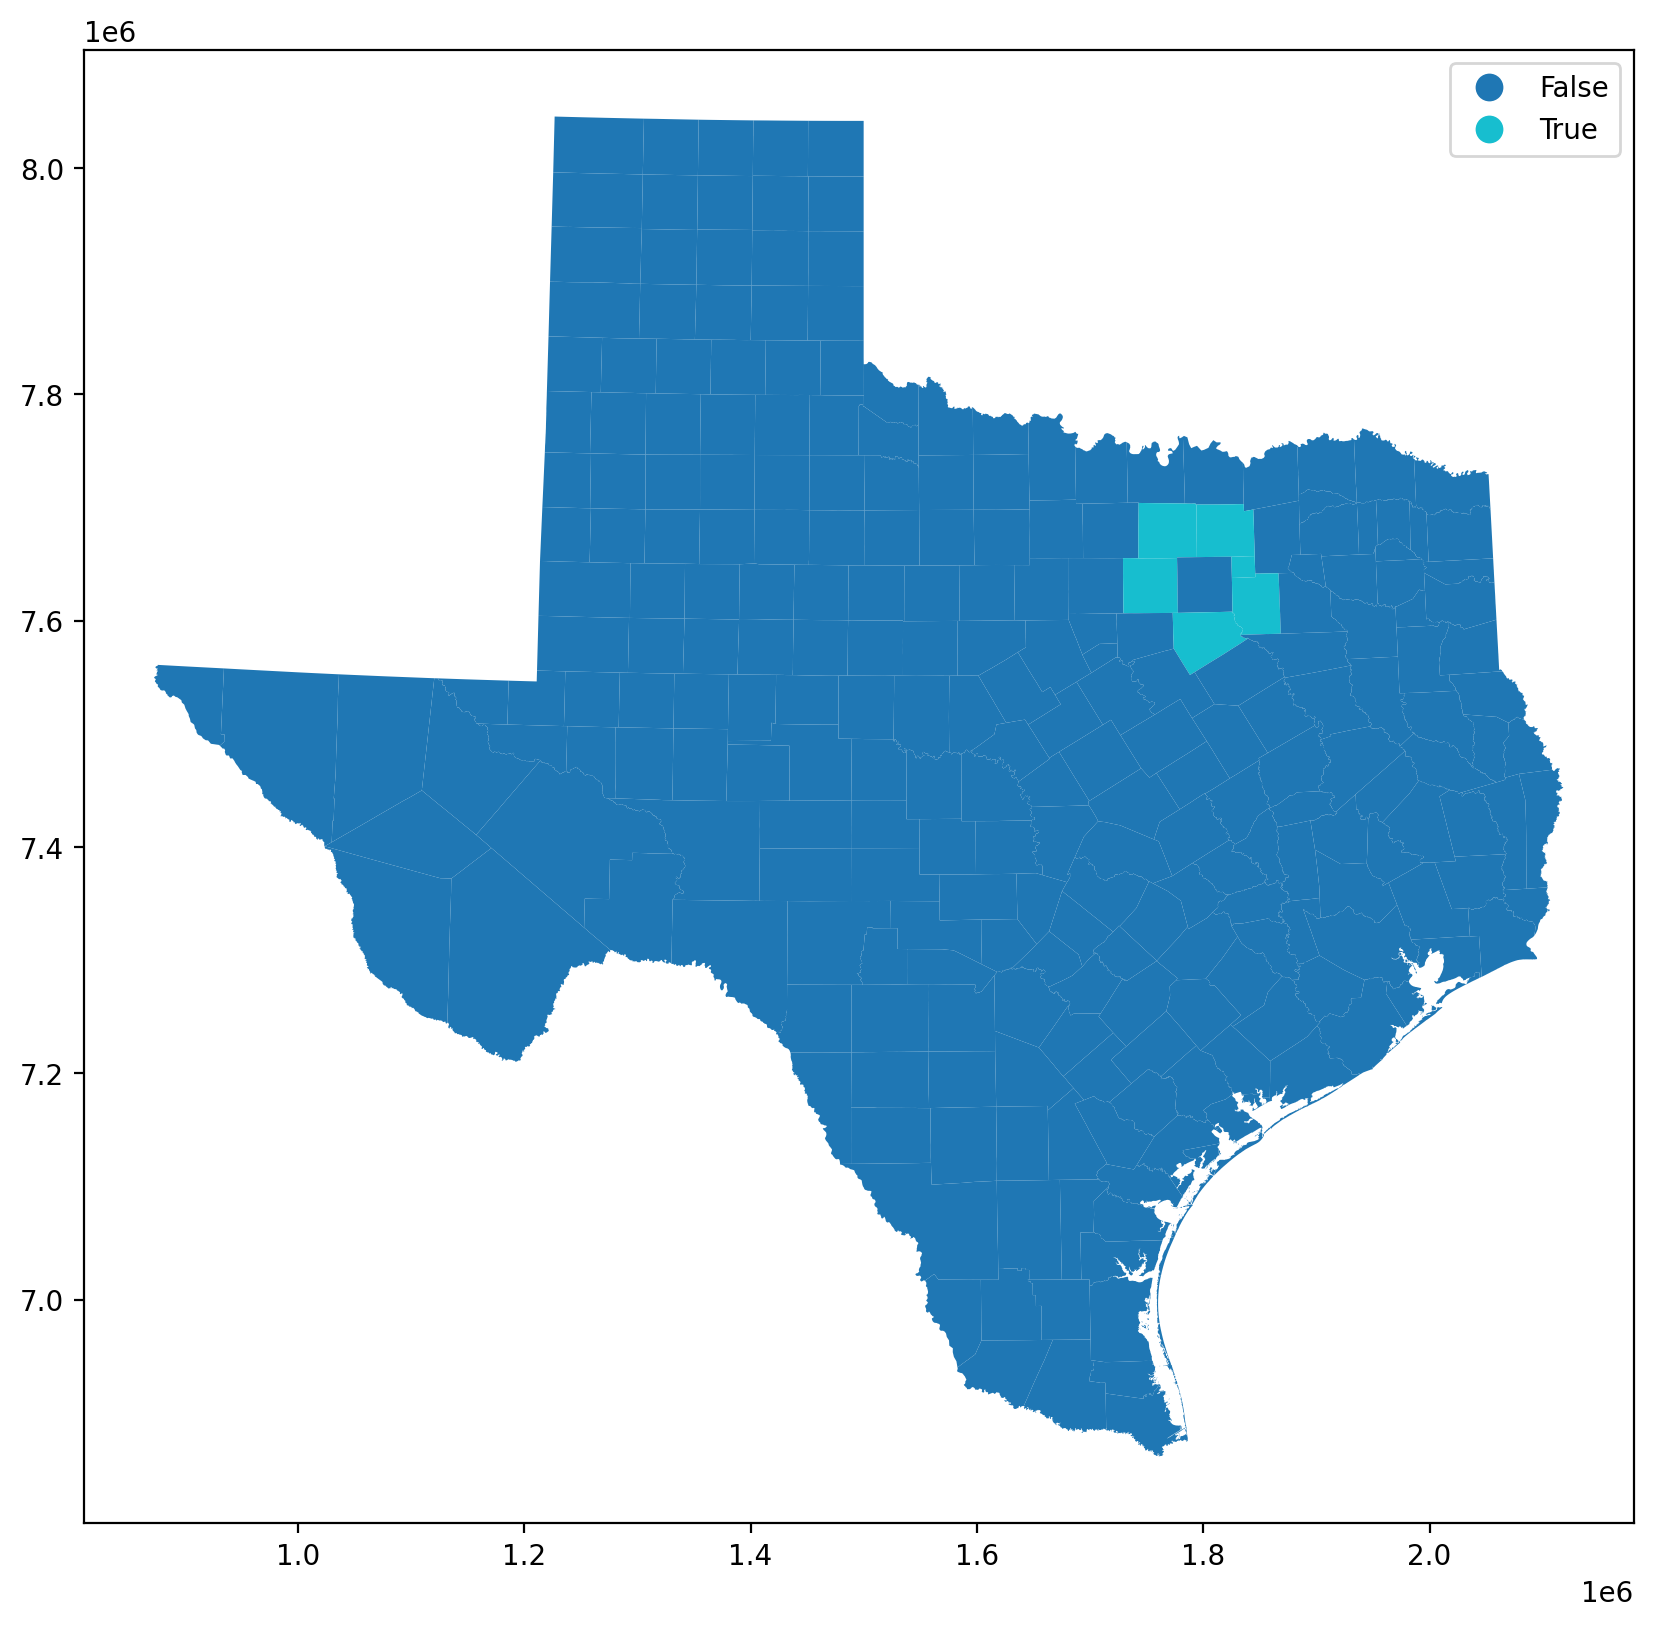

In [42]:
counties_projected.plot(column="touches_dallas", categorical=True, legend=True, figsize=(10, 10));

We can also ask which counties intersect our Dallas buffer.

In [43]:
counties_projected["intersects_dallas_buffer"] = counties_projected.intersects(dallas_buffer)

In [44]:
counties_projected[counties_projected["intersects_dallas_buffer"]][["COUNTY", "intersects_dallas_buffer"]].head(20)

,COUNTY,intersects_dallas_buffer
37,Montague County,True
39,Grayson County,True
40,Cooke County,True
41,Lamar County,True
42,Fannin County,True
53,Delta County,True
54,Jack County,True
55,Wise County,True
56,Denton County,True
57,Hunt County,True


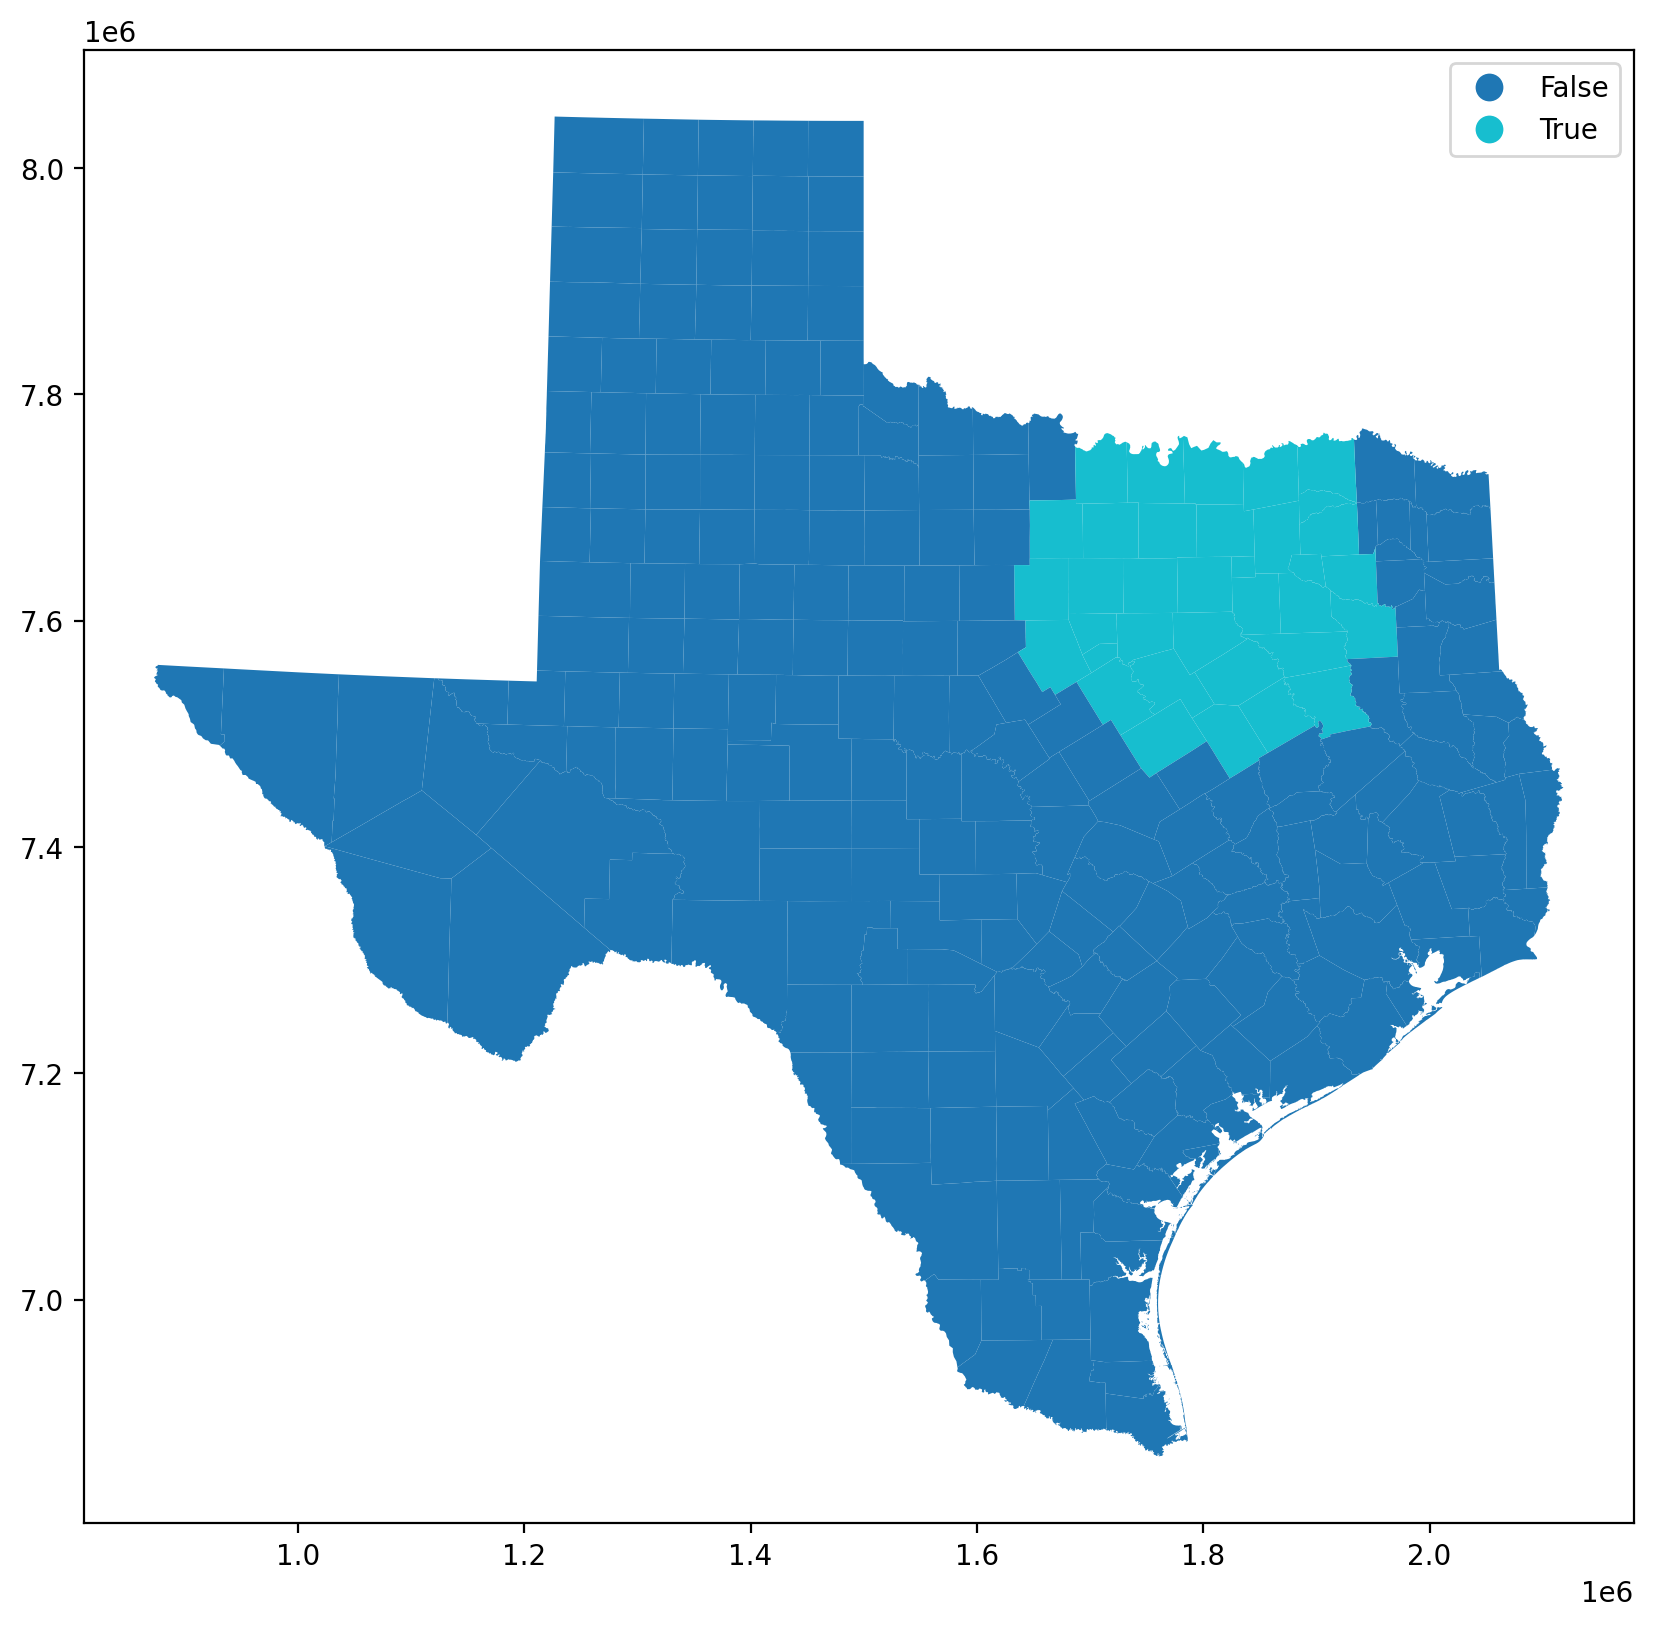

In [45]:
counties_projected.plot(column="intersects_dallas_buffer", categorical=True, legend=True, figsize=(10, 10));

# 8. Merging Census Data with Geography

Now we will connect this mapping work to the ACS dataset from the
previous session.

In [ ]:
acs = pd.read_csv("data/texas_ACS_2024_sample.csv")

In [ ]:
acs.head()

The ACS file has long column names. Let’s clean them up.

In [ ]:
acs = acs.rename(columns={
    "name": "county",
    "Total Population": "population",
    "Population 16 years and over in labor force": "labor_force",
    "Population 25 years and over with Bachelors Degree or higher": "bachelors_degree",
    "Population 16 and over with income in the past 12 months below poverty level": "poverty_population",
    "Households with Internet Subscription": "internet_households",
    "Total Population in Renter Occupied Housing": "renters",
    "Median Household Income in the Past 12 Months (In 2024 Inflation-adjusted Dollars)": "median_income",
    "Total Population in Owner Occupied Housing": "owners"
})

The GeoJSON file uses a five-digit county FIPS code. The ACS file stores
that FIPS code at the end of the `geoid` field.

In [ ]:
acs["FIPS"] = acs["geoid"].str[-5:]

Let’s create a few rates that are easier to compare across counties than
raw totals.

In [ ]:
acs["poverty_rate"] = acs["poverty_population"] / acs["labor_force"]
acs["bachelors_rate"] = acs["bachelors_degree"] / acs["population"]
acs["internet_rate"] = acs["internet_households"] / (acs["owners"] + acs["renters"])
acs["renter_rate"] = acs["renters"] / (acs["owners"] + acs["renters"])

In [ ]:
acs[["county", "FIPS", "population", "median_income", "poverty_rate", "internet_rate"]].head()

Now we can merge the ACS data onto the county shapes.

In [ ]:
mapped = counties_projected.merge(acs, on="FIPS", how="left")

In [ ]:
mapped.head()

Check whether the merge worked.

In [ ]:
mapped[["COUNTY", "county", "population", "median_income"]].head()

# 9. Choropleth Maps

A choropleth map colors areas based on a data value.

Let’s map median household income.

In [ ]:
mapped.plot(
    column="median_income",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2
);

This map is more informative if we remove the axes.

In [ ]:
ax = mapped.plot(
    column="median_income",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2
)
ax.set_axis_off();

## You Try

Map `poverty_rate` instead of `median_income`.

In [ ]:

# Your code here


# 10. Totals vs Rates

Raw totals often mostly show where the most people live.

Rates can reveal different kinds of patterns.

Compare total population with internet access rate.

In [ ]:
ax = mapped.plot(
    column="population",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2
)
ax.set_axis_off();

In [ ]:
ax = mapped.plot(
    column="internet_rate",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2
)
ax.set_axis_off();

## Discussion

What does the population map show clearly?

What does the internet access map show that the population map does not?

# 11. Classifying Values

Sometimes maps are easier to read if values are grouped into categories.

One common option is to use quantiles, which divide counties into groups
with similar numbers of counties in each group.

In [ ]:
ax = mapped.plot(
    column="median_income",
    scheme="quantiles",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2
)
ax.set_axis_off();

## Discussion

How does this map differ from the previous income map?

Which version is easier to interpret?

# 12. Adding the Parks Dataset

Now we will add a second dataset: Texas state parks by county.

This dataset gives us a good example of a variable that is interesting,
geographic, and not obviously connected to the ACS variables.

In [ ]:
parks = pd.read_csv("data/texas_state_parks_by_county.csv")

If your file has a slightly different name, update the path above.

In [ ]:
parks.head()

Clean the parks data so the FIPS code matches our other datasets.

In [ ]:
parks["FIPS"] = parks["geoid"].str[-5:]
parks = parks.rename(columns={"state_park_count": "parks"})

In [ ]:
parks.head()

Merge parks onto our mapped data.

In [ ]:
mapped = mapped.merge(parks[["FIPS", "parks"]], on="FIPS", how="left")

In [ ]:
mapped[["COUNTY", "parks"]].head(10)

Some counties do not have state parks in this dataset.

That gives us a chance to talk about missing data.

In [ ]:
mapped["parks"].isna().sum()

# 13. Mapping Missing Data

GeoPandas ignores missing values by default.

In [ ]:
ax = mapped.plot(
    column="parks",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2
)
ax.set_axis_off();

We can make the missing data visible using `missing_kwds`.

In [ ]:
ax = mapped.plot(
    column="parks",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "red",
        "hatch": "///",
        "label": "No state park listed"
    }
)
ax.set_axis_off();

Missing data is not always a problem to hide. Sometimes it is part of
the story.

# 14. Filling Missing Values

In this case, a missing value probably means the county has zero state
parks in the parks dataset.

Let’s create a filled version.

In [ ]:
mapped["parks_filled"] = mapped["parks"].fillna(0)

In [ ]:
ax = mapped.plot(
    column="parks_filled",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2
)
ax.set_axis_off();

## Discussion

Is it reasonable to replace missing park values with zero?

When would filling missing values be dangerous?

# 15. Comparing Maps

Now we can compare the parks map to ACS variables.

For example:

- Are parks concentrated in high-income counties?
- Are parks concentrated in rural counties?
- Are parks related to population?
- Are parks just showing geography and land availability?

In [ ]:
mapped.plot.scatter(x="parks_filled", y="median_income");

In [ ]:
mapped.plot.scatter(x="parks_filled", y="population");

In [ ]:
mapped.plot.scatter(x="parks_filled", y="poverty_rate");

## Discussion

Do these relationships look strong, weak, or messy?

What might explain the pattern?

What might be misleading?

# 16. Layering Maps

We can layer different geometries on the same map.

For example, we can map county income and overlay county centroids.

In [ ]:
ax = mapped.plot(
    column="median_income",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.2
)
mapped.set_geometry("centroid").plot(ax=ax, color="black", markersize=3)
ax.set_axis_off();

This is a simple example, but layering is a very important idea in
spatial analysis.

# 17. Pulling it all together: Parks Within 100 km of a County

Now let's tie several spatial ideas together.

Suppose we want to ask:

> How many state parks could someone plausibly drive to within 100 km of a given county?

This example uses:
- projections
- centroids
- buffers
- spatial relationships
- missing data
- counting and summarizing

### Important Limitation

Our parks dataset counts parks by county, but it does not include the exact latitude and longitude of each park.

So this is an approximation.

We will estimate nearby parks by counting parks in counties whose centroids fall within 100 km of the selected county.

A better version of this analysis would use the actual point locations of each state park.

In [ ]:
# Choose a county
selected_county = "Dallas County"

target_county = counties_projected[
    counties_projected["COUNTY"] == selected_county
]

target_county

In [ ]:
# Create a 100 km buffer around that county
buffer_100km = target_county.geometry.buffer(100000).iloc[0]

In [ ]:
# Merge park counts onto our projected county data
counties_with_parks = counties_projected.merge(
    parks,
    left_on="FIPS",
    right_on="FIPS",
    how="left"
)

In [ ]:
# Counties with no matching park record should have zero parks
counties_with_parks["parks"] = (
    counties_with_parks["parks"].fillna(0)
)

In [ ]:
# Identify counties whose centroids fall within the 100 km buffer
counties_with_parks["within_100km"] = (
    counties_with_parks["centroid"].within(buffer_100km)
)

In [ ]:
# Count the estimated number of nearby parks
nearby_parks = counties_with_parks[
    counties_with_parks["within_100km"]
]["parks"].sum()

print(nearby_parks)

In [ ]:
# Show the counties included in the estimate
counties_with_parks[
    counties_with_parks["within_100km"]
][["COUNTY", "parks"]].sort_values(
    by="parks",
    ascending=False
)

In [ ]:
# Plot the result
ax = counties_projected.plot(
    color="white",
    edgecolor="lightgray",
    figsize=(10, 10)
)

# Highlight the selected county
target_county.plot(
    ax=ax,
    color="orange",
    edgecolor="black"
)

# Draw the 100 km buffer
gpd.GeoSeries([buffer_100km], crs=counties_projected.crs).plot(
    ax=ax,
    color="none",
    edgecolor="red",
    linewidth=2
)

# Highlight counties whose centroids are within the buffer
counties_with_parks[counties_with_parks["within_100km"]].plot(
    ax=ax,
    color="lightblue",
    edgecolor="black",
    alpha=0.5
)

# Plot county centroids, scaled by park count
counties_with_parks.set_geometry("centroid").plot(
    ax=ax,
    markersize=counties_with_parks["parks"] * 10,
    color="green",
    alpha=0.7
)

ax.set_title(
    f"Estimated state parks within 100 km of {selected_county} County: {nearby_parks}"
)

ax.set_axis_off()

### Discussion

What assumptions did we make?

- We used county centroids instead of exact park locations.
- We counted all parks in a county if that county's centroid was within the buffer.
- We used a straight-line distance, not actual driving distance.
- We did not consider roads, traffic, park size, or park quality.

This is still useful because it shows how spatial analysis can help us build an approximate answer when perfect data is not available.

# 18. Mini-Challenge

Create one map that surprises you.

Choose one variable from the dataset and make a map.

Possible variables:

- `population`
- `median_income`
- `poverty_rate`
- `bachelors_rate`
- `internet_rate`
- `renter_rate`
- `parks_filled`
- `SQUARE_MIL`
- `distance_to_dallas`

Your map should include:

1.  a variable
2.  a legend
3.  no axes
4.  a short interpretation

In [ ]:

# Your map here


What pattern do you see?

Why might this pattern exist?

What might be misleading about this map?

# AI Assistant Checkpoint

Try asking an AI assistant one of the following:

- Explain what a geometry column is in GeoPandas.
- Explain the difference between a choropleth map and a scatterplot.
- Why can raw totals be misleading on maps?
- What does it mean for two polygons to touch or intersect?
- Help me improve this GeoPandas map without changing the data.

AI tools are most useful when you ask them to explain, debug, or
critique your work.

# Wrap-Up

Today we learned that spatial data is more than just a picture.

We used GeoPandas to:

- load county boundaries
- map geometries
- calculate areas, centroids, distances, and buffers
- test spatial relationships
- merge ACS data with county shapes
- map missing values
- compare geographic patterns

The most important idea is:

> Geography changes how we interpret data.